# クラスタ分析テンプレート

## 分析の流れ

1. データの読込（生成）・前処理
2. K-means クラスタリング（全データ）
3. 階層クラスタリング（全データ）
4. 謝絶データのみ K-means
5. 謝絶データのみ 階層クラスタリング

## ライブラリ

In [1]:
# Standard

# 3rd party
import japanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

## sklearn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

## scipy
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

# 表示設定
pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", "{:.2f}".format)
#sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100

# ---- 定数 ----
TARGET_COL = 'label'   # ★ ターゲット列名
POS_LABEL  = '開設'    # ★ 正例ラベル
NEG_LABEL  = '謝絶'    # ★ 負例ラベル
RANDOM_STATE = 42

# クラスタカラーパレット（最大8クラスタ対応）
CLUSTER_PALETTE = sns.color_palette('tab10', 8)
CLASS_COLORS = {POS_LABEL: '#4C72B0', NEG_LABEL: '#DD8452'}

## データ準備・前処理

In [2]:
# ---- ▼ サンプルデータ生成（実データに差し替えてください） ----
np.random.seed(RANDOM_STATE)
n = 2000
df = pd.DataFrame({
    TARGET_COL              : np.random.choice([POS_LABEL, NEG_LABEL], n, p=[0.65, 0.35]),
    'age'                   : np.random.normal(40, 12, n).clip(18, 80).astype(int),
    'annual_income'         : np.random.lognormal(6.5, 0.6, n).round(-3),
    'employment_years'      : np.random.exponential(5, n).clip(0, 40).round(1),
    'num_existing_accounts' : np.random.poisson(1.2, n),
    'credit_score'          : np.random.normal(620, 80, n).clip(300, 900).astype(int),
    'employment_type'       : np.random.choice(['正社員','契約社員','自営業','無職'], n, p=[0.55,0.2,0.15,0.1]),
    'residence_type'        : np.random.choice(['持家','賃貸','その他'], n, p=[0.45,0.45,0.1]),
    'has_other_bank'        : np.random.choice(['あり','なし'], n, p=[0.6,0.4]),
})
# ---- ▲ サンプルデータここまで ----

# ---- 数値列・カテゴリ列の自動抽出 ----
num_cols = df.select_dtypes(include='number').columns.tolist()
cat_cols = [c for c in df.select_dtypes(include='object').columns if c != TARGET_COL]

# ---- カテゴリ変数をダミー変換 ----
df_encoded = pd.get_dummies(df.drop(columns=[TARGET_COL]), columns=cat_cols, drop_first=True)

# ---- 欠損補完（中央値）----
df_encoded = df_encoded.fillna(df_encoded.median(numeric_only=True))

# ---- 標準化 ----
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_encoded)
feature_names = df_encoded.columns.tolist()

print(f'全データ: {X_scaled.shape[0]:,} 件 / 特徴量: {X_scaled.shape[1]} 個')
print(f'謝絶データ: {(df[TARGET_COL]==NEG_LABEL).sum():,} 件')

全データ: 2,000 件 / 特徴量: 11 個
謝絶データ: 699 件


/var/folders/6x/0whm9kbs4bg6p6xq6w7vsm0r0000gn/T/ipykernel_95632/2436937482.py:19: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = [c for c in df.select_dtypes(include='object').columns if c != TARGET_COL]


In [3]:
# ---- PCA（2次元に圧縮して可視化用）----
# PCAとは？ 多次元データを「重要な方向」に圧縮して2次元で見やすくする技術です
# カメラで3D物体を2Dの写真に撮るイメージ
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_ * 100
print(f'PCA 累積寄与率: {explained.sum():.1f}% (PC1={explained[0]:.1f}%, PC2={explained[1]:.1f}%)')

df_vis = pd.DataFrame({'PC1': X_pca[:,0], 'PC2': X_pca[:,1], TARGET_COL: df[TARGET_COL].values})

PCA 累積寄与率: 30.3% (PC1=16.8%, PC2=13.5%)


## PartA：全データ（開設＋謝絶）のクラスタ分析

### 2. K-Means クラスタリング（全データ）

> **K-Meansとは？**<br>
> あらかじめ「K個のグループに分ける」と決めてから分類する手法です。<br>
> 引越し業者が「倉庫をK箇所作るとしたら、どこが最適か」を考えるイメージです。<br>
> まずエルボー法でKの最適値を探します。

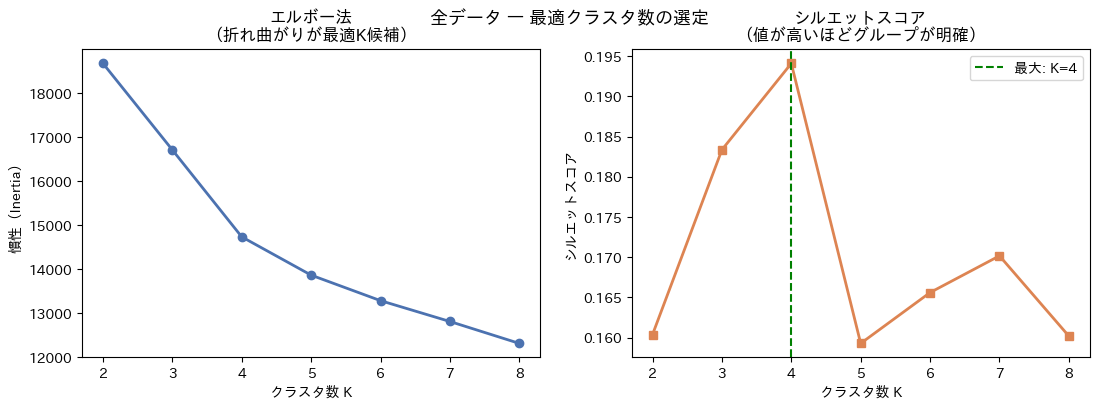


👉 シルエットスコアで最適な K = 4


In [4]:
# ---- エルボー法 & シルエットスコアで最適K探索 ----
k_range = range(2, 9)
inertias, sil_scores = [], []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels, sample_size=500))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_range, inertias, 'o-', color='#4C72B0', linewidth=2)
axes[0].set_xlabel('クラスタ数 K')
axes[0].set_ylabel('慣性（Inertia）')
axes[0].set_title('エルボー法\n（折れ曲がりが最適K候補）', fontsize=12)
axes[0].set_xticks(list(k_range))

axes[1].plot(k_range, sil_scores, 's-', color='#DD8452', linewidth=2)
axes[1].set_xlabel('クラスタ数 K')
axes[1].set_ylabel('シルエットスコア')
axes[1].set_title('シルエットスコア\n（値が高いほどグループが明確）', fontsize=12)
axes[1].set_xticks(list(k_range))

best_k_sil = list(k_range)[np.argmax(sil_scores)]
axes[1].axvline(best_k_sil, color='green', linestyle='--', label=f'最大: K={best_k_sil}')
axes[1].legend()

plt.suptitle('全データ — 最適クラスタ数の選定', fontsize=13)
#plt.tight_layout()
plt.show()
print(f'\n👉 シルエットスコアで最適な K = {best_k_sil}')

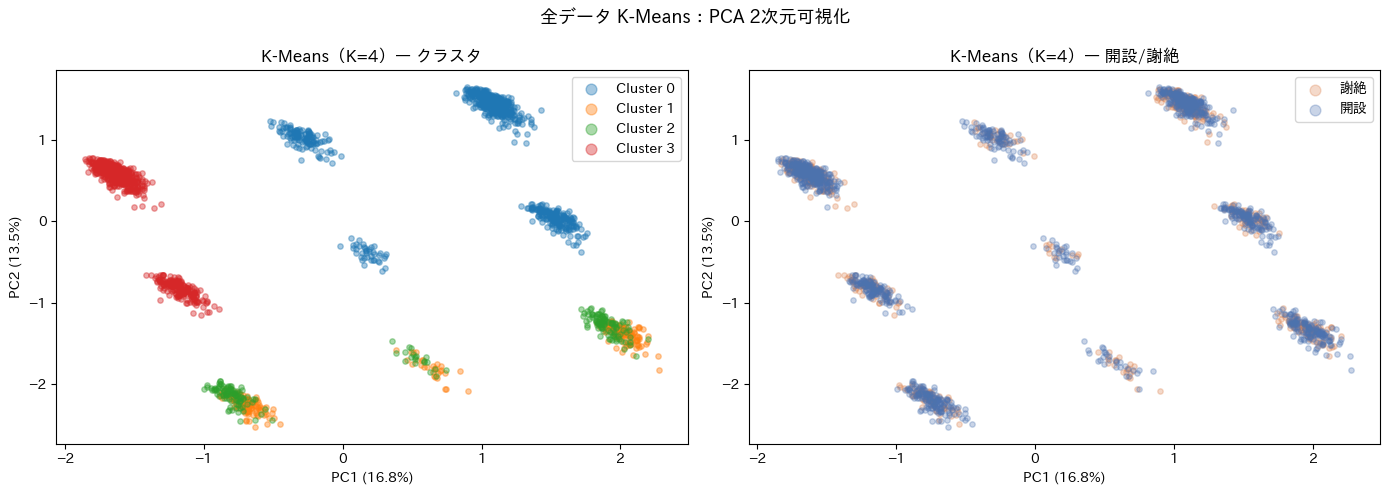

In [5]:
# ---- K-Means 実行 ----
K_ALL = best_k_sil   # ★ 手動で変更も可: K_ALL = 4

km_all = KMeans(n_clusters=K_ALL, random_state=RANDOM_STATE, n_init=10)
df_vis['cluster_km'] = km_all.fit_predict(X_scaled).astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# クラスタ別に散布図
for cl, grp in df_vis.groupby('cluster_km'):
    axes[0].scatter(grp['PC1'], grp['PC2'], alpha=0.4, s=15,
                    label=f'Cluster {cl}', color=CLUSTER_PALETTE[int(cl)])
axes[0].set_title(f'K-Means（K={K_ALL}）— クラスタ', fontsize=12)
axes[0].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[0].legend(markerscale=2)

# 開設/謝絶で色分け（同じ散布図）
for label, grp in df_vis.groupby(TARGET_COL):
    axes[1].scatter(grp['PC1'], grp['PC2'], alpha=0.3, s=15,
                    label=label, color=CLASS_COLORS[label])
axes[1].set_title(f'K-Means（K={K_ALL}）— 開設/謝絶', fontsize=12)
axes[1].set_xlabel(f'PC1 ({explained[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({explained[1]:.1f}%)')
axes[1].legend(markerscale=2)

plt.suptitle('全データ K-Means：PCA 2次元可視化', fontsize=13)
plt.tight_layout()
plt.show()

=== クラスタ別 件数・謝絶率 ===


,件数,謝絶率(%)
cluster_km_all,,
3,714,36.80
1,285,35.80
0,785,33.50
2,216,32.90



=== クラスタ別 数値変数の平均 ===


,age,annual_income,employment_years,num_existing_accounts,credit_score
cluster_km_all,,,,,
0,39.70,783.40,4.60,1.20,618.70
1,40.30,764.90,4.70,1.30,618.40
2,39.00,810.20,5.50,1.20,619.60
3,39.90,712.90,4.50,1.20,617.00


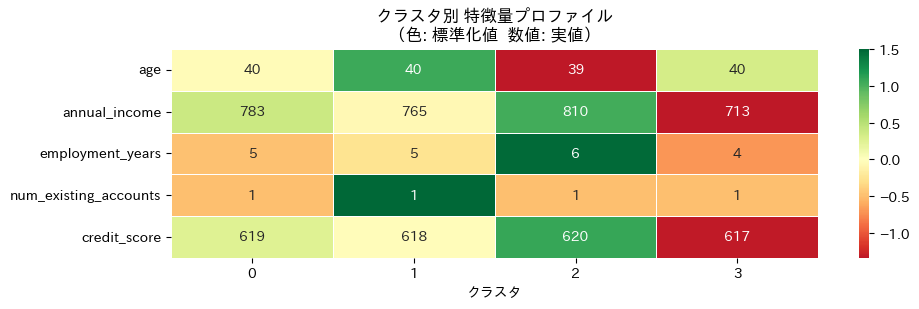

In [6]:
# ---- クラスタ別：謝絶率・特徴量平均 ----
df['cluster_km_all'] = df_vis['cluster_km'].values

rejection_by_cluster = (
    df.groupby('cluster_km_all')[TARGET_COL]
    .apply(lambda x: (x == NEG_LABEL).mean() * 100)
    .rename('謝絶率(%)')
    .round(1)
)
count_by_cluster = df.groupby('cluster_km_all').size().rename('件数')
cluster_summary = pd.concat([count_by_cluster, rejection_by_cluster], axis=1).sort_values('謝絶率(%)', ascending=False)

print('=== クラスタ別 件数・謝絶率 ===')
display(cluster_summary)

# 数値変数の平均をクラスタ別に表示
cluster_profile = df.groupby('cluster_km_all')[num_cols].mean().round(1)
print('\n=== クラスタ別 数値変数の平均 ===')
display(cluster_profile)

# ヒートマップで可視化
cluster_profile_std = (cluster_profile - cluster_profile.mean()) / cluster_profile.std()
fig, ax = plt.subplots(figsize=(10, max(3, K_ALL * 0.8)))
sns.heatmap(cluster_profile_std.T, annot=cluster_profile.T, fmt='.0f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('クラスタ別 特徴量プロファイル\n（色: 標準化値  数値: 実値）', fontsize=12)
ax.set_xlabel('クラスタ')
plt.tight_layout()
plt.show()

### 3. 階層クラスタリング（全データ）

> **階層クラスタリングとは？**<br>
> 「似たもの同士を少しずつ合体させていく」手法。<br>
> 家系図のように枝分かれした樹形図（デンドログラム）で結果を可視化できる。<br>
> Kを事前に決めなくていいのが利点ですがデータが多いと重くなる。

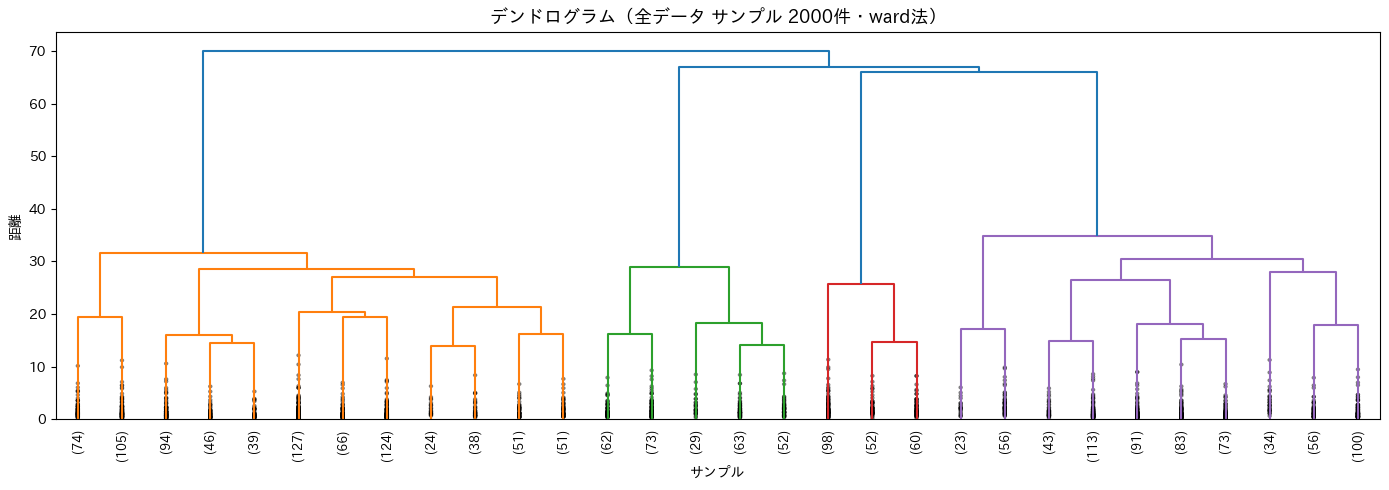

In [7]:
# 大量データだとデンドログラムが重くなるため、サンプリングして表示
HIER_SAMPLE = len(X_scaled)   # ★ サンプル数（全件使いたい場合は len(X_scaled) に変更）
idx_sample = np.random.choice(len(X_scaled), HIER_SAMPLE, replace=False)
X_hier = X_scaled[idx_sample]
label_hier = df[TARGET_COL].values[idx_sample]

# リンケージ計算（ward法）
Z = linkage(X_hier, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9, show_contracted=True)
ax.set_title(f'デンドログラム（全データ サンプル {HIER_SAMPLE}件・ward法）', fontsize=13)
ax.set_xlabel('サンプル')
ax.set_ylabel('距離')
plt.tight_layout()
plt.show()

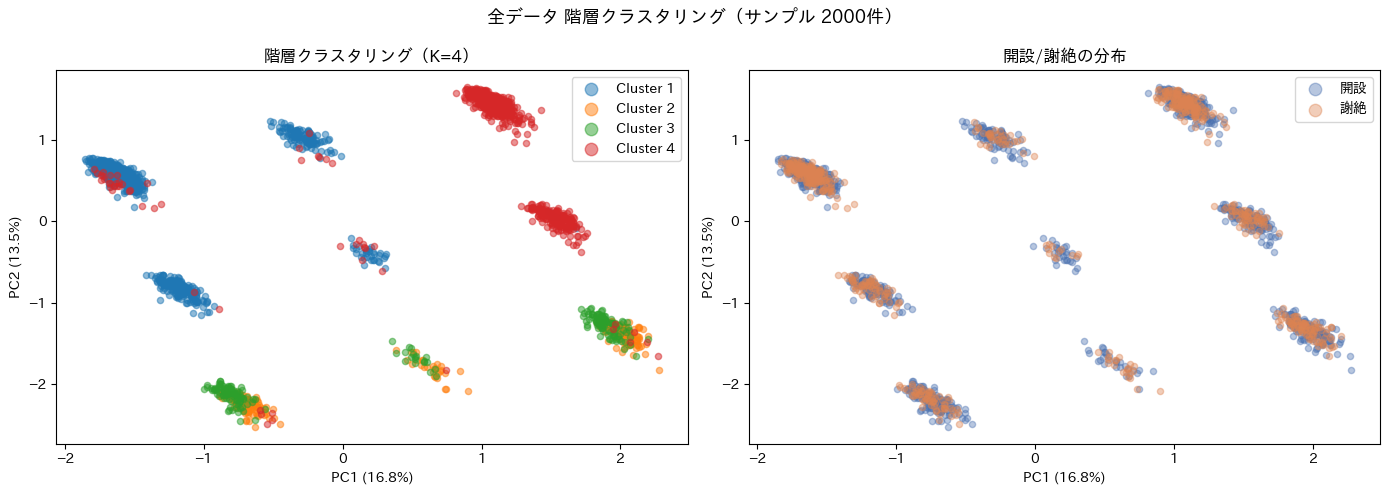

=== 階層クラスタ別 件数・謝絶率 ===


,件数,謝絶率(%)
cluster,,
2,279,35.80
1,839,35.20
4,672,34.80
3,210,33.30


In [8]:
# ---- 階層クラスタリングでラベル付け ----
K_HIER_ALL = K_ALL   # ★ デンドログラムを見て変更してください
hier_labels = fcluster(Z, t=K_HIER_ALL, criterion='maxclust').astype(str)

# PCA可視化（サンプル分のみ）
pca_hier = PCA(n_components=2, random_state=RANDOM_STATE)
X_hier_pca = pca_hier.fit_transform(X_hier)
exp_hier = pca_hier.explained_variance_ratio_ * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for cl in sorted(set(hier_labels)):
    mask = hier_labels == cl
    axes[0].scatter(X_hier_pca[mask, 0], X_hier_pca[mask, 1],
                    alpha=0.5, s=20, label=f'Cluster {cl}',
                    color=CLUSTER_PALETTE[int(cl)-1])
axes[0].set_title(f'階層クラスタリング（K={K_HIER_ALL}）', fontsize=12)
axes[0].set_xlabel(f'PC1 ({exp_hier[0]:.1f}%)')
axes[0].set_ylabel(f'PC2 ({exp_hier[1]:.1f}%)')
axes[0].legend(markerscale=2)

for label in [POS_LABEL, NEG_LABEL]:
    mask = label_hier == label
    axes[1].scatter(X_hier_pca[mask, 0], X_hier_pca[mask, 1],
                    alpha=0.4, s=20, label=label, color=CLASS_COLORS[label])
axes[1].set_title('開設/謝絶の分布', fontsize=12)
axes[1].set_xlabel(f'PC1 ({exp_hier[0]:.1f}%)')
axes[1].set_ylabel(f'PC2 ({exp_hier[1]:.1f}%)')
axes[1].legend(markerscale=2)

plt.suptitle(f'全データ 階層クラスタリング（サンプル {HIER_SAMPLE}件）', fontsize=13)
plt.tight_layout()
plt.show()

# クラスタ別 謝絶率
result_hier = pd.DataFrame({'cluster': hier_labels, TARGET_COL: label_hier})
rej_hier = (
    result_hier.groupby('cluster')[TARGET_COL]
    .apply(lambda x: (x == NEG_LABEL).mean() * 100).round(1)
    .rename('謝絶率(%)')
)
count_hier = result_hier.groupby('cluster').size().rename('件数')
print('=== 階層クラスタ別 件数・謝絶率 ===')
display(pd.concat([count_hier, rej_hier], axis=1).sort_values('謝絶率(%)', ascending=False))

---

## PartB：謝絶データのみのクラスタ分析

> **なぜ謝絶だけを深掘りするのか？**<br>
> 「なぜ断られたのか」の理由は複数パターンあるはずです。<br>
> 収入が低いグループ・信用スコアが低いグループ...などを特定することで、<br>
> 対策や審査ルールの見直しに活かすことができる。<br>


In [9]:
# ---- 謝絶データのみ抽出・前処理 ----
rej_mask = df[TARGET_COL] == NEG_LABEL
df_rej = df[rej_mask].reset_index(drop=True)
df_rej_encoded = pd.get_dummies(df_rej.drop(columns=[TARGET_COL,
                    'cluster_km_all'] if 'cluster_km_all' in df_rej.columns else [TARGET_COL]),
                    columns=cat_cols, drop_first=True)
df_rej_encoded = df_rej_encoded.fillna(df_rej_encoded.median(numeric_only=True))
# 列を全データと揃える
for col in feature_names:
    if col not in df_rej_encoded.columns:
        df_rej_encoded[col] = 0
df_rej_encoded = df_rej_encoded[feature_names]

scaler_rej = StandardScaler()
X_rej_scaled = scaler_rej.fit_transform(df_rej_encoded)

pca_rej = PCA(n_components=2, random_state=RANDOM_STATE)
X_rej_pca = pca_rej.fit_transform(X_rej_scaled)
exp_rej = pca_rej.explained_variance_ratio_ * 100

print(f'謝絶データ: {X_rej_scaled.shape[0]:,} 件')

謝絶データ: 699 件


### 4. K-Means クラスタリング（謝絶のみ）

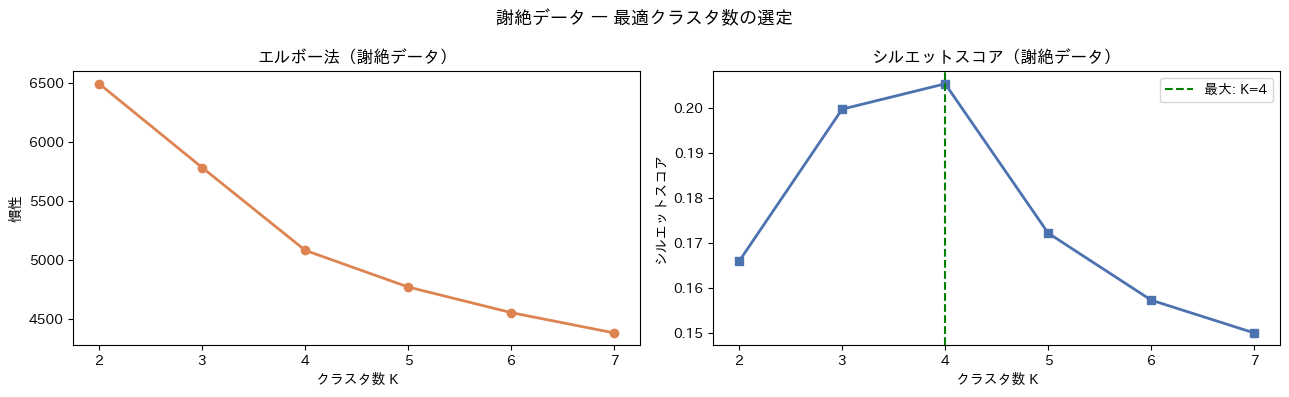


👉 謝絶データの最適 K = 4


In [10]:
# ---- エルボー法 & シルエットスコア ----
k_range_rej = range(2, min(8, len(df_rej)//20))
inertias_rej, sil_rej = [], []

for k in k_range_rej:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    lbl = km.fit_predict(X_rej_scaled)
    inertias_rej.append(km.inertia_)
    sil_rej.append(silhouette_score(X_rej_scaled, lbl, sample_size=min(300, len(df_rej))))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(k_range_rej, inertias_rej, 'o-', color='#DD8452', linewidth=2)
axes[0].set_xlabel('クラスタ数 K'); axes[0].set_ylabel('慣性')
axes[0].set_title('エルボー法（謝絶データ）'); axes[0].set_xticks(list(k_range_rej))

best_k_rej = list(k_range_rej)[np.argmax(sil_rej)]
axes[1].plot(k_range_rej, sil_rej, 's-', color='#4C72B0', linewidth=2)
axes[1].axvline(best_k_rej, color='green', linestyle='--', label=f'最大: K={best_k_rej}')
axes[1].set_xlabel('クラスタ数 K'); axes[1].set_ylabel('シルエットスコア')
axes[1].set_title('シルエットスコア（謝絶データ）'); axes[1].set_xticks(list(k_range_rej))
axes[1].legend()

plt.suptitle('謝絶データ — 最適クラスタ数の選定', fontsize=13)
plt.tight_layout()
plt.show()
print(f'\n👉 謝絶データの最適 K = {best_k_rej}')

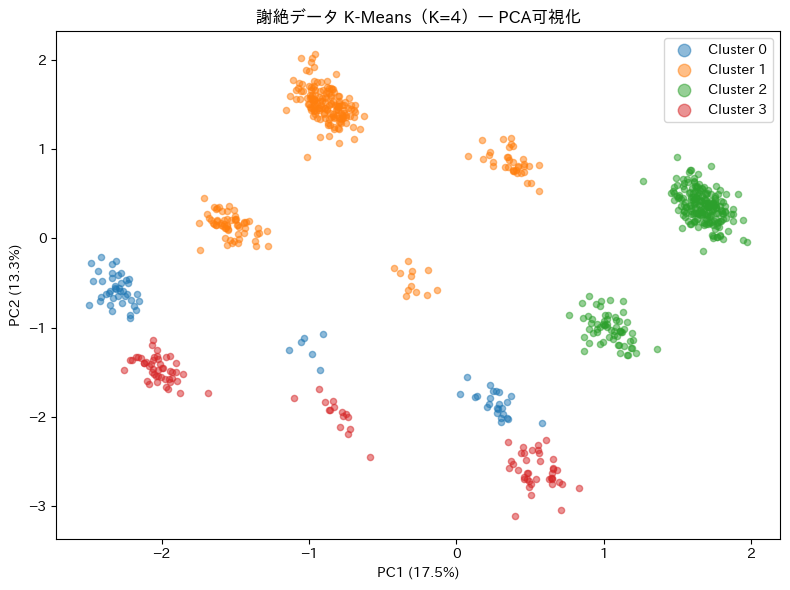

=== 謝絶クラスタ別 件数・特徴量平均 ===


,件数,age,annual_income,employment_years,num_existing_accounts,credit_score
cluster_km,,,,,,
0,71,39.40,746.50,5.80,1.30,614.60
1,263,39.30,756.70,4.40,1.20,617.60
2,263,40.40,684.40,4.80,1.10,617.50
3,102,41.10,754.90,4.00,1.20,615.00


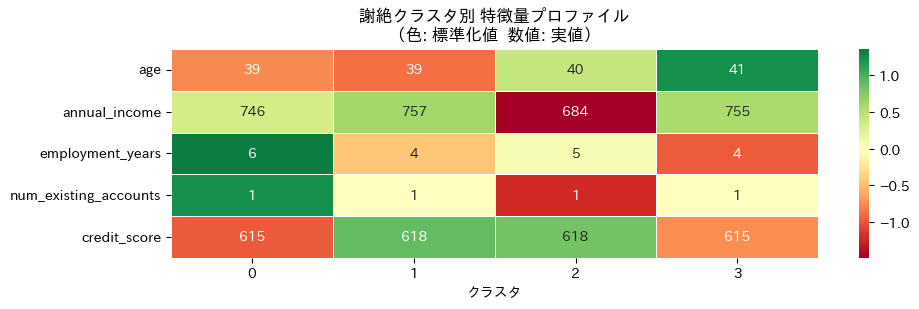

In [11]:
# ---- K-Means 実行（謝絶） ----
K_REJ = best_k_rej   # ★ 手動変更可

km_rej = KMeans(n_clusters=K_REJ, random_state=RANDOM_STATE, n_init=10)
df_rej['cluster_km'] = km_rej.fit_predict(X_rej_scaled).astype(str)

fig, ax = plt.subplots(figsize=(8, 6))
for cl, grp_idx in df_rej.groupby('cluster_km').groups.items():
    ax.scatter(X_rej_pca[grp_idx, 0], X_rej_pca[grp_idx, 1],
               alpha=0.5, s=20, label=f'Cluster {cl}',
               color=CLUSTER_PALETTE[int(cl)])
ax.set_title(f'謝絶データ K-Means（K={K_REJ}）— PCA可視化', fontsize=12)
ax.set_xlabel(f'PC1 ({exp_rej[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({exp_rej[1]:.1f}%)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

# 特徴量プロファイル
rej_profile = df_rej.groupby('cluster_km')[num_cols].mean().round(1)
rej_count   = df_rej.groupby('cluster_km').size().rename('件数')
print('=== 謝絶クラスタ別 件数・特徴量平均 ===')
display(pd.concat([rej_count, rej_profile], axis=1))

rej_profile_std = (rej_profile - rej_profile.mean()) / rej_profile.std()
fig, ax = plt.subplots(figsize=(10, max(3, K_REJ * 0.8)))
sns.heatmap(rej_profile_std.T, annot=rej_profile.T, fmt='.0f',
            cmap='RdYlGn', center=0, ax=ax, linewidths=0.5,
            annot_kws={'size': 10})
ax.set_title('謝絶クラスタ別 特徴量プロファイル\n（色: 標準化値  数値: 実値）', fontsize=12)
ax.set_xlabel('クラスタ')
plt.tight_layout()
plt.show()

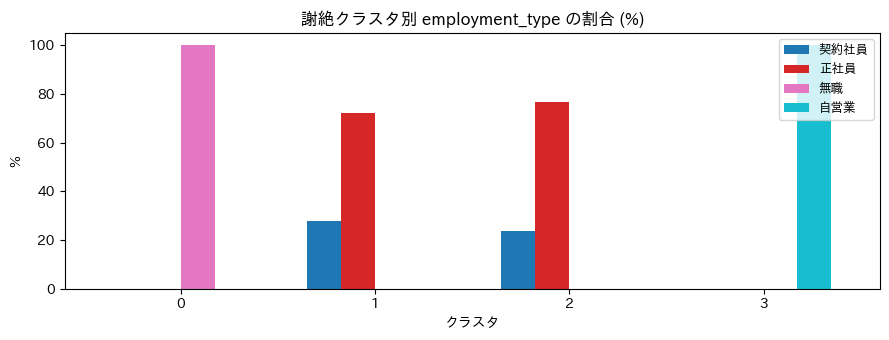

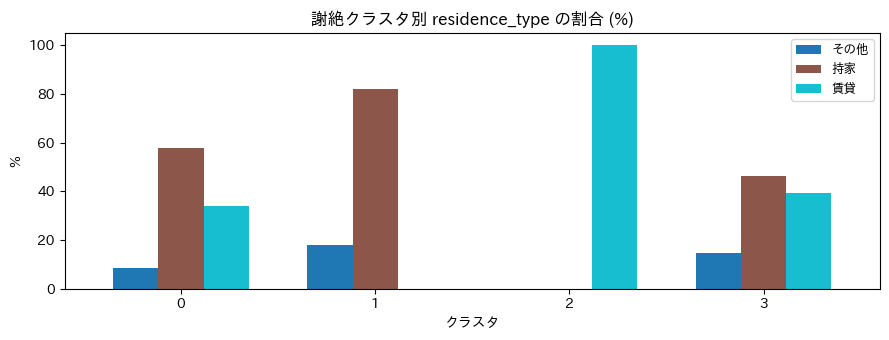

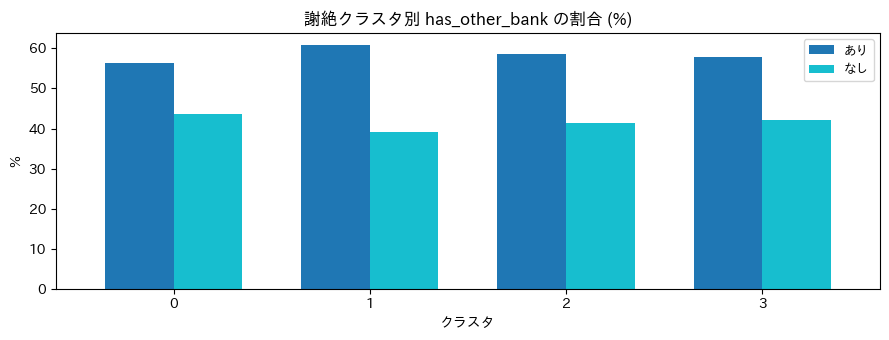

In [12]:
# ---- カテゴリ変数の分布（謝絶クラスタ別） ----
for col in cat_cols:
    ct = pd.crosstab(df_rej['cluster_km'], df_rej[col], normalize='index') * 100
    ct.plot(kind='bar', figsize=(9, 3.5), colormap='tab10', width=0.7)
    plt.title(f'謝絶クラスタ別 {col} の割合 (%)')
    plt.ylabel('%')
    plt.xlabel('クラスタ')
    plt.xticks(rotation=0)
    plt.legend(loc='upper right', fontsize=9)
    plt.tight_layout()
    plt.show()

### 5. 階層クラスタリング（謝絶のみ）

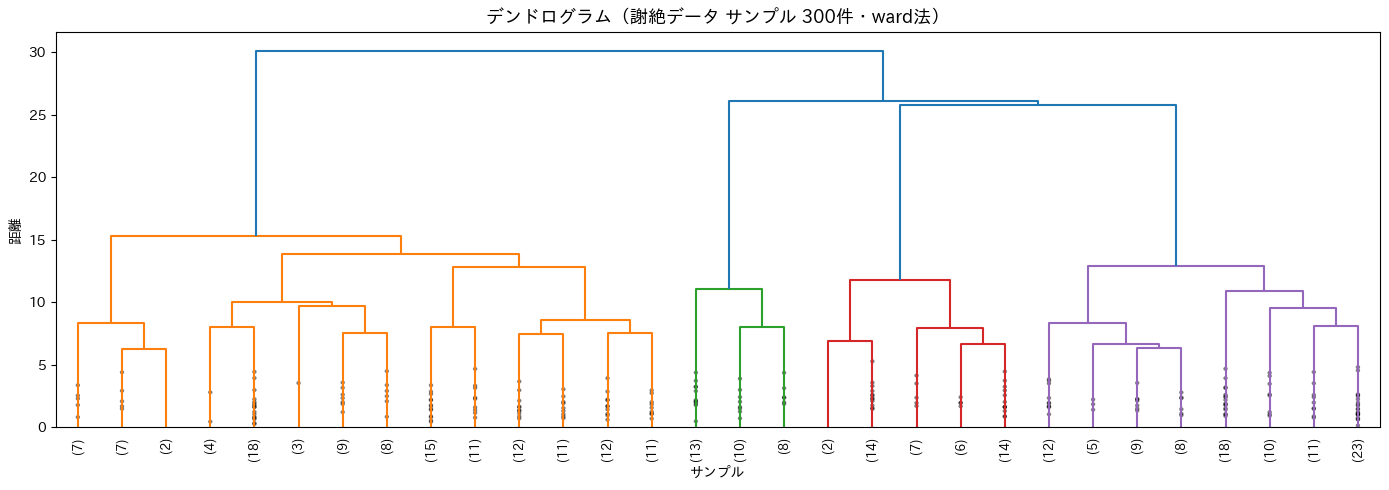

In [13]:
HIER_SAMPLE_REJ = min(300, len(df_rej))
idx_rej_sample = np.random.choice(len(X_rej_scaled), HIER_SAMPLE_REJ, replace=False)
X_rej_hier = X_rej_scaled[idx_rej_sample]

Z_rej = linkage(X_rej_hier, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z_rej, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9, show_contracted=True)
ax.set_title(f'デンドログラム（謝絶データ サンプル {HIER_SAMPLE_REJ}件・ward法）', fontsize=13)
ax.set_xlabel('サンプル')
ax.set_ylabel('距離')
plt.tight_layout()
plt.show()

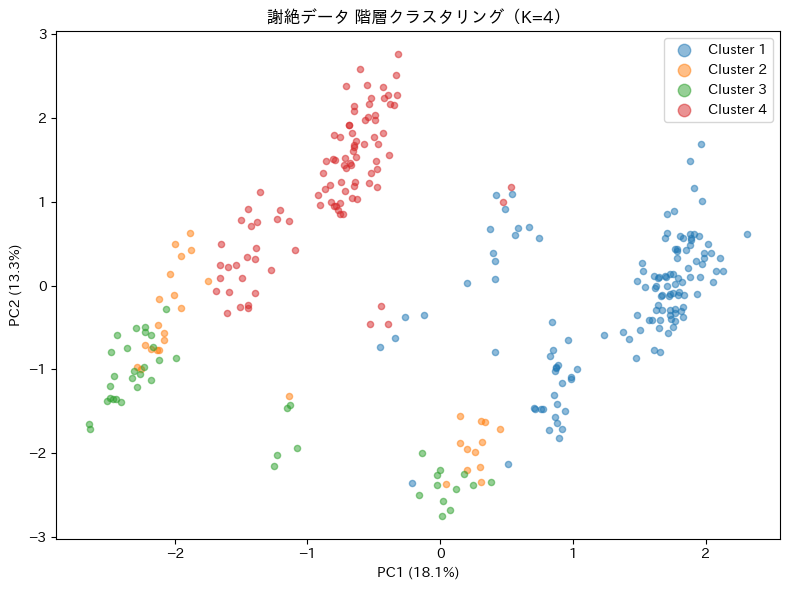

=== 謝絶 階層クラスタ別 件数・特徴量平均 ===


,件数,age,annual_income,employment_years,num_existing_accounts,credit_score
cluster_hier,,,,,,
1,130,40.50,692.30,5.00,1.20,616.20
2,31,37.30,709.70,5.00,1.30,613.70
3,43,40.10,720.90,4.50,0.90,599.30
4,96,41.10,625.00,4.70,1.50,612.90


In [14]:
K_HIER_REJ = K_REJ   # ★ デンドログラムを見て変更
hier_rej_labels = fcluster(Z_rej, t=K_HIER_REJ, criterion='maxclust').astype(str)

pca_rej_h = PCA(n_components=2, random_state=RANDOM_STATE)
X_rej_h_pca = pca_rej_h.fit_transform(X_rej_hier)
exp_rej_h = pca_rej_h.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(8, 6))
for cl in sorted(set(hier_rej_labels)):
    mask = hier_rej_labels == cl
    ax.scatter(X_rej_h_pca[mask, 0], X_rej_h_pca[mask, 1],
               alpha=0.5, s=20, label=f'Cluster {cl}',
               color=CLUSTER_PALETTE[int(cl)-1])
ax.set_title(f'謝絶データ 階層クラスタリング（K={K_HIER_REJ}）', fontsize=12)
ax.set_xlabel(f'PC1 ({exp_rej_h[0]:.1f}%)')
ax.set_ylabel(f'PC2 ({exp_rej_h[1]:.1f}%)')
ax.legend(markerscale=2)
plt.tight_layout()
plt.show()

# 特徴量プロファイル
df_rej_sample = df_rej.iloc[idx_rej_sample].copy()
df_rej_sample['cluster_hier'] = hier_rej_labels
hier_rej_profile = df_rej_sample.groupby('cluster_hier')[num_cols].mean().round(1)
hier_rej_count   = df_rej_sample.groupby('cluster_hier').size().rename('件数')
print('=== 謝絶 階層クラスタ別 件数・特徴量平均 ===')
display(pd.concat([hier_rej_count, hier_rej_profile], axis=1))